In [ ]:
%pip install diffinytrace.zip

Processing ./diffinytrace.zip
  Preparing metadata (setup.py) ... done
  Created wheel for diffinytrace: filename=diffinytrace-2.1-py3-none-any.whl size=93999 sha256=3f99db94a611a24595188576670b44c705bcb2ec6f93926a8efb771cf7bdfb2b
  Stored in directory: /tmp/pip-ephem-wheel-cache-gi5w98ww/wheels/70/69/4f/ea4fe5be2f8364573c110f26b2b32d6dd0dd84ab84341234f7
Successfully built diffinytrace
  Attempting uninstall: diffinytrace
    Found existing installation: diffinytrace 2.1
    Uninstalling diffinytrace-2.1:
      Successfully uninstalled diffinytrace-2.1


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
from os import listdir
from os.path import isfile, join
path = "gdrive/MyDrive/results_final"


Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


num of conv points should probably be at least  251.99999999999997


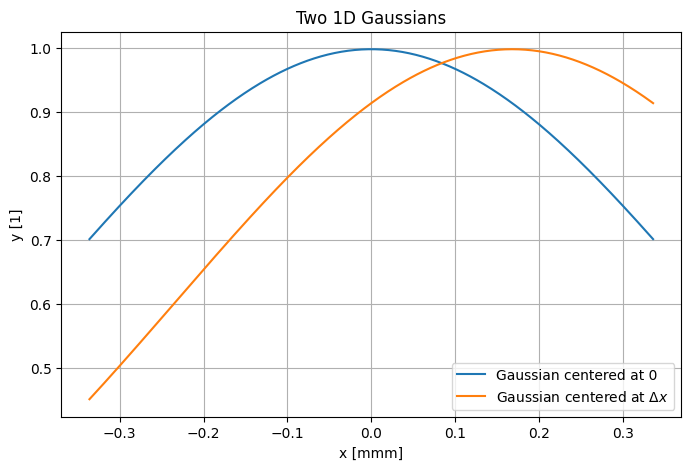

<Figure size 640x480 with 0 Axes>

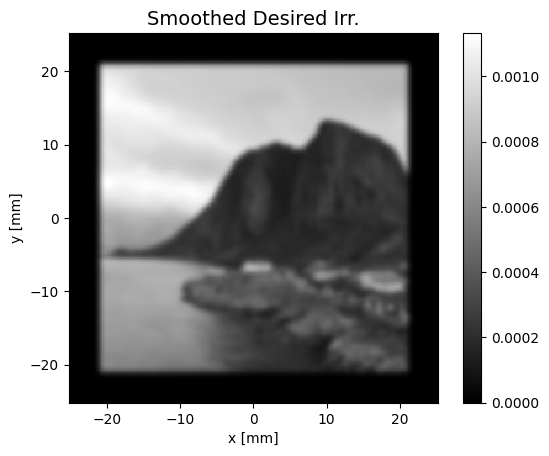

orders [3, 3]
ns [4, 4]
using sigmas [0.4, 0.4, 0.4, 0.4, 0.4, 0.4, 0.4]


/usr/local/lib/python3.11/dist-packages/torch/functional.py:539: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:3637.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


is valid all== tensor(True, device='cuda:0')
run_minimization_loop_classical
BEGIN: opti after refine: coeff shape: torch.Size([4, 4])
END
BEGIN: opti after refine: coeff shape: torch.Size([6, 6])
END
BEGIN: opti after refine: coeff shape: torch.Size([10, 10])
END
BEGIN: opti after refine: coeff shape: torch.Size([18, 18])
END
BEGIN: opti after refine: coeff shape: torch.Size([34, 34])
END
BEGIN: opti after refine: coeff shape: torch.Size([66, 66])
END
BEGIN: opti after refine: coeff shape: torch.Size([130, 130])
END
BEGIN: opti after refine: coeff shape: torch.Size([258, 258])
END
number of unset coefficients:  tensor(19040., device='cuda:0', dtype=torch.float32)
number of unset coefficients:  tensor(5282., device='cuda:0', dtype=torch.float32)
number of unset coefficients:  tensor(4986., device='cuda:0', dtype=torch.float32)
number of unset coefficients:  tensor(4692., device='cuda:0', dtype=torch.float32)
number of unset coefficients:  tensor(4400., device='cuda:0', dtype=torch.floa

In [ ]:
#%%
import diffinytrace as dit
from sunlight_picture import create_lens
import os
import pickle
import gc

def save_data(data, filename):
    with open(filename, 'wb') as file:
        pickle.dump(data, file)
    print(f"Data saved to {filename}")

def load_data(filename):
    with open(filename, 'rb') as file:
        data = pickle.load(file)
    print(f"Data loaded from {filename}")
    return data

def create_folder(folder_path):
    try:
        os.makedirs(folder_path, exist_ok=True)
        return f"Folder created successfully at: {folder_path}" if not os.path.exists(folder_path) else f"Folder already exists at: {folder_path}"
    except Exception as e:
        return f"An error occurred: {e}"

device = "cuda:0"
image_file_name = "img1.jpg"
results_folder_main = path+"/results_NV1"
create_folder(results_folder_main)
sigma_final = 0.4

sigmas = None
ns_start = [4,4]
orders = [3,3]
num_refinements = 7

aperture_radius_source = 21.
image_padding = 0.2
grid_size = 300
num_rays = 2**19
num_integration_points_desired=2**21
#[1601,1601]
from diffinytrace import utils
#from diffinytrace.nonimaging import smoothing
aperture_radius_detector = aperture_radius_source*(1+image_padding)

print("num of conv points should probably be at least ", 2.0*aperture_radius_detector*2.0/sigma_final)

import numpy as np
import matplotlib.pyplot as plt

# Parameters
dx = (aperture_radius_detector*2.0)/grid_size
x = np.linspace(-dx*2, dx*2, 500)  # x-axis range

# Gaussian 1 centered at 0
gaussian1 = (1 / (sigma_final * np.sqrt(2 * np.pi))) * np.exp(-x**2 / (2 * sigma_final**2))

# Gaussian 2 centered at dx
gaussian2 = (1 / (sigma_final * np.sqrt(2 * np.pi))) * np.exp(-(x - dx)**2 / (2 * sigma_final**2))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(x, gaussian1, label='Gaussian centered at 0')
plt.plot(x, gaussian2, label=f'Gaussian centered at $\Delta x$')
plt.title("Two 1D Gaussians")
plt.xlabel("x [mmm]")
plt.ylabel("y [1]")
plt.legend()
plt.grid()
plt.show()

gc.collect()
irr_func = utils.irradiance_importer.create_irradiance_from_image_square(image_file_name,image_padding,0.,aperture_radius_detector)

#quantity2D.plot(final_smoother.desired_smooth_irradiance.cpu().detach().numpy(),"Smoothed Desired Irr.",aperture_radius_detector,cmap="gray")
#plt.imshow(final_smoother.desired_smooth_irradiance.cpu().detach().numpy()[::-1])
#%%
def make_run(subfolder_main,use_desired_irradiance_smoothing):
    create_folder(subfolder_main)
    subfolder = subfolder_main

    #create_folder(subfolder)
    kwargs = dict(image_file_name=image_file_name,
                lens_material=dit.materials["PMMA"],
                air_material=dit.materials["NONE"],
                device=device,
                sigma=sigma_final,
                use_desired_irradiance_smoothing=use_desired_irradiance_smoothing,
                num_rays=num_rays,
                grid_size=grid_size)
                
    results = create_lens(**kwargs)
    save_data(results, subfolder+"/results_dict.pkl")
    del results
    gc.collect()

def run_all_methods():

    
    gc.collect()
    subfolder_main = results_folder_main+"/results_classical"
    make_run(subfolder_main,use_desired_irradiance_smoothing = False)
    
    gc.collect()

    subfolder_main = results_folder_main+"/results_desired_irr_smoothing"
    make_run(subfolder_main,use_desired_irradiance_smoothing = True)
    
    gc.collect()


run_all_methods()


In [ ]:
#import os
#os.kill(os.getpid(), 9)